# Import thư viện

In [32]:
from vnstock import *
import pandas as pd
import matplotlib.pyplot as plt

# Crawl data

In [33]:
# Mã bán lẻ
symbols = ['DGW', 'FRT', 'DHT']
bank_symbols = ['VIB', 'LPB', 'STB']

In [35]:
stock = Vnstock().stock(symbol='CMV', source='VCI')

In [39]:
import time
merge = pd.DataFrame()
for symbol in symbols:
    df = stock.quote.history(symbol=symbol, start='2023-01-01', end='2025-03-31', interval='1D')
    df['symbol'] = symbol
    merge = pd.concat([merge, df], ignore_index=True)
    time.sleep(1)

In [41]:
import time
merge2 = pd.DataFrame()
for symbol in bank_symbols:
    df = stock.quote.history(symbol=symbol, start='2023-01-01', end='2025-03-31', interval='1D')
    df['symbol'] = symbol
    merge2 = pd.concat([merge, df], ignore_index=True)
    time.sleep(1)

In [40]:
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1671 non-null   datetime64[ns]
 1   open    1671 non-null   float64       
 2   high    1671 non-null   float64       
 3   low     1671 non-null   float64       
 4   close   1671 non-null   float64       
 5   volume  1671 non-null   int64         
 6   symbol  1671 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 91.5+ KB


In [44]:
merge2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2228 entries, 0 to 2227
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    2228 non-null   datetime64[ns]
 1   open    2228 non-null   float64       
 2   high    2228 non-null   float64       
 3   low     2228 non-null   float64       
 4   close   2228 non-null   float64       
 5   volume  2228 non-null   int64         
 6   symbol  2228 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 122.0+ KB


In [7]:
merge.to_csv('Ma_ban_le.csv', index=False)

In [45]:
merge2.to_csv('Ma_ngan_hang.csv', index=False)

# Phân tích

In [18]:
stock = pd.read_csv('Ma_ban_le.csv')

In [19]:
stock['time'] = pd.to_datetime(stock['time'])
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1671 non-null   datetime64[ns]
 1   open    1671 non-null   float64       
 2   high    1671 non-null   float64       
 3   low     1671 non-null   float64       
 4   close   1671 non-null   float64       
 5   volume  1671 non-null   int64         
 6   symbol  1671 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 91.5+ KB


In [26]:
from matplotlib import dates
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0] 

def show_plt(symbol):
    time_stock = stock[stock['symbol'] == symbol]['time']
    value_stock = stock[stock['symbol'] == symbol]['close']
    volume_stock = stock[stock['symbol'] == symbol]['volume']

#   plt.figure(figsize=(10, 6))
#   plt.plot(time_stock, growth_index_per_day(value_stock), color='red', label=f"{symbol} growth")
#   plt.bar(time_stock, volume_stock, color='skyblue', label=f"{symbol} volume")

#   plt.gca().xaxis.set_major_locator(dates.MonthLocator(interval=3))
#   plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
#   plt.gcf().autofmt_xdate()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Trục trái: Line plot cho tăng trưởng
    ax1.plot(time_stock, growth_index_per_day(value_stock), color='red', label=f"{symbol} growth (%)")
    ax1.set_ylabel("Growth (%)", color='red')
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True)

    # Format ngày tháng
    ax1.xaxis.set_major_locator(dates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
    fig.autofmt_xdate()

    # Trục phải: Bar chart cho volume
    ax2 = ax1.twinx()
    ax2.bar(time_stock, volume_stock, color='darkblue', alpha=0.4, label=f"{symbol} volume")
    ax2.set_ylabel("Volume", color='blue')
    ax2.tick_params(axis='y', labelcolor='darkblue')


    plt.grid(True)
    plt.legend(loc='upper left')  # Đảm bảo legend hiển thị

    plt.title(f"{symbol} growth vs volume", fontsize=16)

    plt.show()

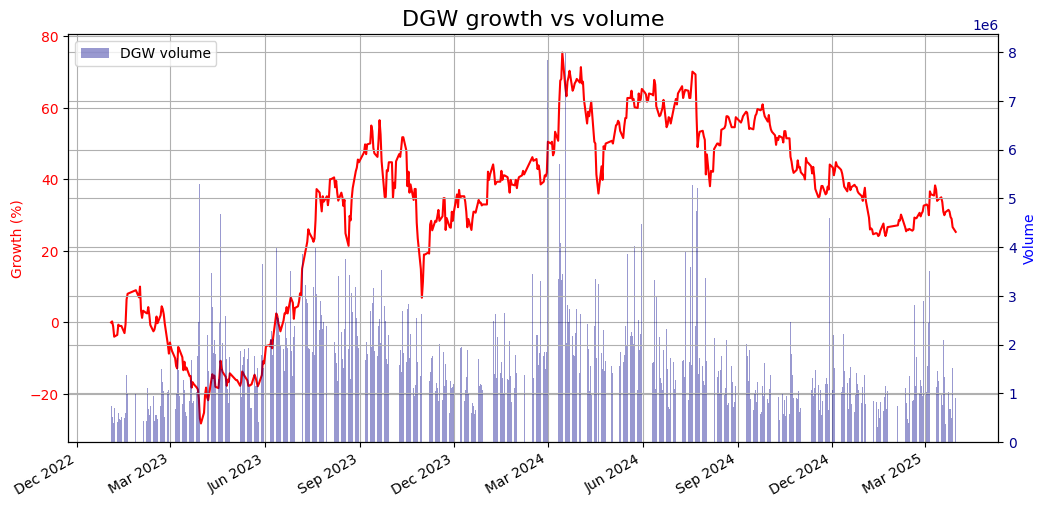

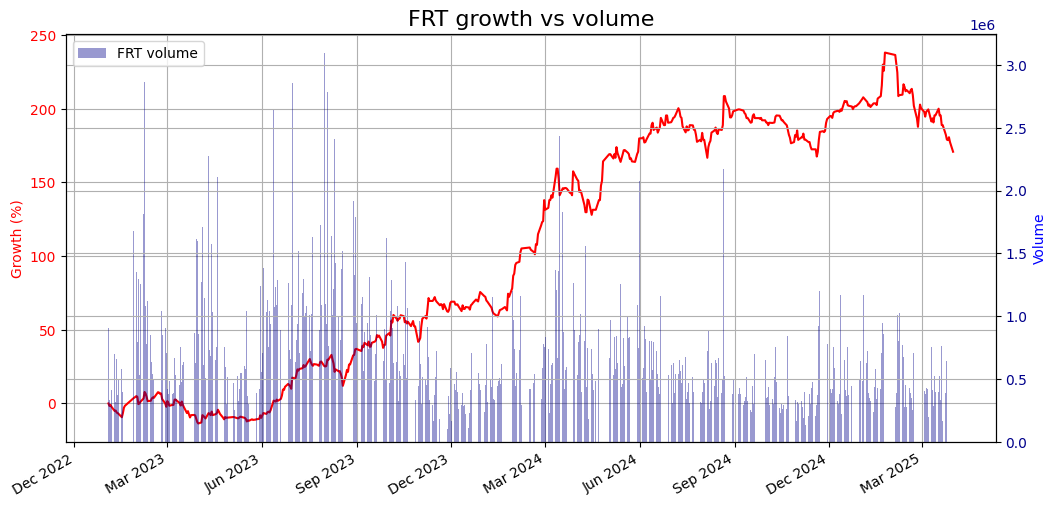

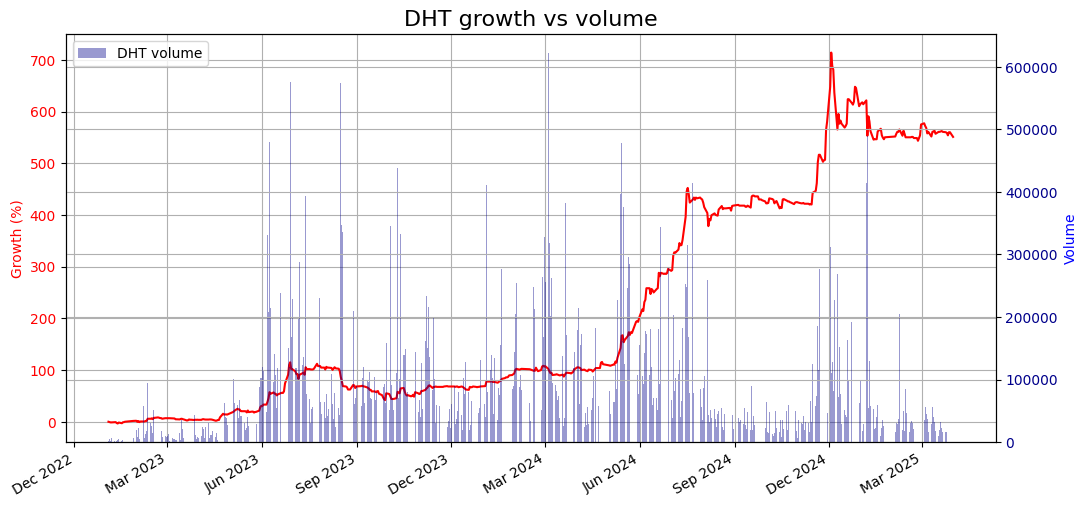

In [27]:
for symbol in symbols:
    show_plt(symbol)

In [85]:
# Chọn cổ phiếu
retail = ['DGW', 'FRT', 'DHT']
bank = ['VIB', 'LPB', 'STB']
symbols = bank + retail

In [56]:
import time
merge = pd.DataFrame()
for symbol in symbols:
    df = stock.quote.history(symbol=symbol, start='2022-01-01', end='2025-03-31', interval='1D')
    df['symbol'] = symbol
    merge = pd.concat([merge, df], ignore_index=True)
    time.sleep(1)

In [58]:
merge.to_csv('six_stock_symbols.csv')

In [68]:
merge_stock = pd.read_csv('six_stock_symbols.csv')

In [69]:
# Lấy volume
volume = merge_stock.groupby('symbol')['volume'].sum()

In [70]:
# Tạo DataFrame
df_volume = pd.DataFrame(volume)

In [75]:
df_volume = df_volume.reset_index()

In [76]:
df_volume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   symbol  6 non-null      object
 1   volume  6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [77]:
# Phân loại
df_volume['group'] = df_volume['symbol'].apply(lambda x: 'bank' if x in bank else 'retail')

In [82]:
# Tính phần trăm
df_volume['percent'] = df_volume['volume'] / df_volume['volume'].sum() * 100
df_volume['label'] = df_volume['symbol'] + ', ' + df_volume['percent'].round(1).astype(str) + '%'

In [80]:
df_volume

,symbol,volume,group,percent,label
0,DGW,1162051830,retail,4.753467,"DGW, 4.8%"
1,DHT,53084816,retail,0.217148,"DHT, 0.2%"
2,FRT,748136970,retail,3.060315,"FRT, 3.1%"
3,LPB,5107280268,bank,20.891744,"LPB, 20.9%"
4,STB,13452625845,bank,55.029056,"STB, 55.0%"
5,VIB,3923225374,bank,16.048271,"VIB, 16.0%"


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


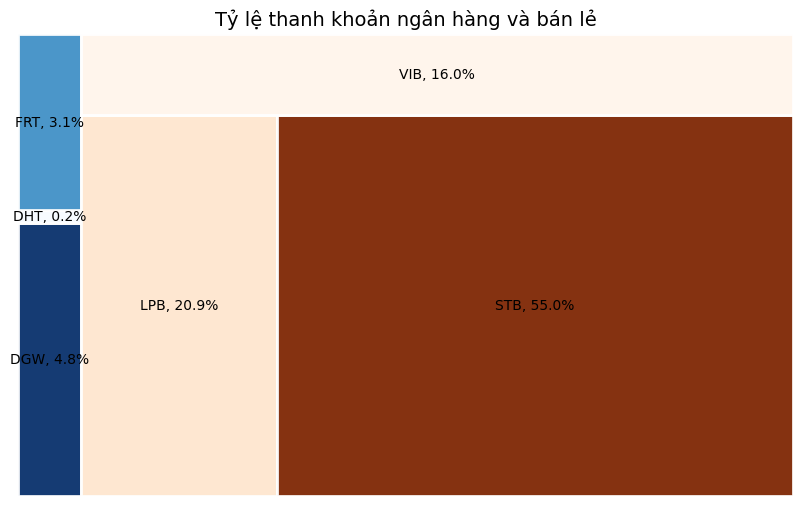

In [97]:
# import squarify

# # Vẽ biểu đồ treemap
# plt.figure(figsize=(10, 6))
# colors = ['lightgreen' if g == 'bank' else 'lightskyblue' for g in df_volume['group']]
# squarify.plot(sizes=df_volume['volume'], label=df_volume['label'], color=colors, alpha=0.8)
# plt.title('Tỷ trọng thanh khoản của 6 cổ phiếu trong ngày (Ngân hàng vs Bán lẻ)', fontsize=14)
# plt.axis('off')
# plt.show()

import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Tạo hai DataFrame: bank và retail
df_bank = df_volume[df_volume['group'] == 'bank']
df_retail = df_volume[df_volume['group'] == 'retail']

# Normalize theo từng nhóm
norm_bank = mcolors.Normalize(vmin=df_bank['percent'].min() , vmax=df_bank['percent'].max())
norm_retail = mcolors.Normalize(vmin=df_retail['percent'].min(), vmax=df_retail['percent'].max())

# Colormap cho từng nhóm
cmap_bank = cm.get_cmap('Oranges')    # Bank: cam - đỏ
cmap_retail = cm.get_cmap('Blues')  # Retail: xanh biển - tím

# Tạo danh sách màu
colors = []
for _, row in df_volume.iterrows():
    if row['group'] == 'bank':
        color = cmap_bank(norm_bank(row['percent']))
    else:
        color = cmap_retail(norm_retail(row['percent']))
    colors.append(color)

# Vẽ treemap
plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=df_volume['volume'],
    label=df_volume['label'],
    color=colors,
    alpha=0.95,
    edgecolor='white',  # viền trắng phân biệt rõ
    linewidth=2
)

plt.title('Tỷ lệ thanh khoản ngân hàng và bán lẻ', fontsize=14)
plt.axis('off')
plt.show()